# Churn Prediction & Retention Optimization using Machine Learning

## *Overview*

- Customer churn is one of the most critical challenges for businesses.
- This project builds an end-to-end machine learning system to identify customers at risk of churning and provides data-driven strategies to improve retention and revenue.

## *Business Objective*

- Predict customer churn with high recall
- Identify high-risk customer segments
- Enable proactive retention strategies
- Improve customer lifetime value (CLV)

## *IMPORT LIBRARIES* 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

## *LOAD DATA*

In [2]:
df = pd.read_csv('customer_data_1000.csv')

In [3]:
print("Shape :", df.shape)
df.head()

Shape : (1000, 9)


,CustomerID,Age,Gender,AnnualIncome,SpendingScore,PurchaseHistory,MembershipDuration,FeedbackScore,ChurnIndicator
0,1,57,Male,103219,8,8,9,9,0
1,2,40,Male,78923,34,16,6,9,0
2,3,31,Female,97537,70,12,6,4,0
3,4,57,Female,74669,68,16,4,5,0
4,5,45,Male,34216,55,13,3,2,0


## *EDA (EXPLORATORY DATA ANALYSIS)*

In [4]:
# Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          1000 non-null   int64 
 1   Age                 1000 non-null   int64 
 2   Gender              1000 non-null   object
 3   AnnualIncome        1000 non-null   int64 
 4   SpendingScore       1000 non-null   int64 
 5   PurchaseHistory     1000 non-null   int64 
 6   MembershipDuration  1000 non-null   int64 
 7   FeedbackScore       1000 non-null   int64 
 8   ChurnIndicator      1000 non-null   int64 
dtypes: int64(8), object(1)
memory usage: 70.4+ KB


In [5]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseHistory,MembershipDuration,FeedbackScore,ChurnIndicator
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.885000,74573.534000,50.330000,9.746000,5.052000,4.921000,0.293000
std,288.819436,14.713064,25547.467517,29.056279,5.336287,2.612302,2.516961,0.455366
min,1.000000,18.000000,30177.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,250.750000,31.000000,52186.750000,25.000000,5.000000,3.000000,3.000000,0.000000
50%,500.500000,44.000000,75699.000000,52.000000,10.000000,5.000000,5.000000,0.000000
75%,750.250000,57.000000,96325.750000,76.000000,14.000000,7.000000,7.000000,1.000000
max,1000.000000,69.000000,119958.000000,99.000000,19.000000,9.000000,9.000000,1.000000


In [6]:
# Missing Values
print("\n Missing Values:\n",df.isnull().sum())


 Missing Values:
 CustomerID            0
Age                   0
Gender                0
AnnualIncome          0
SpendingScore         0
PurchaseHistory       0
MembershipDuration    0
FeedbackScore         0
ChurnIndicator        0
dtype: int64


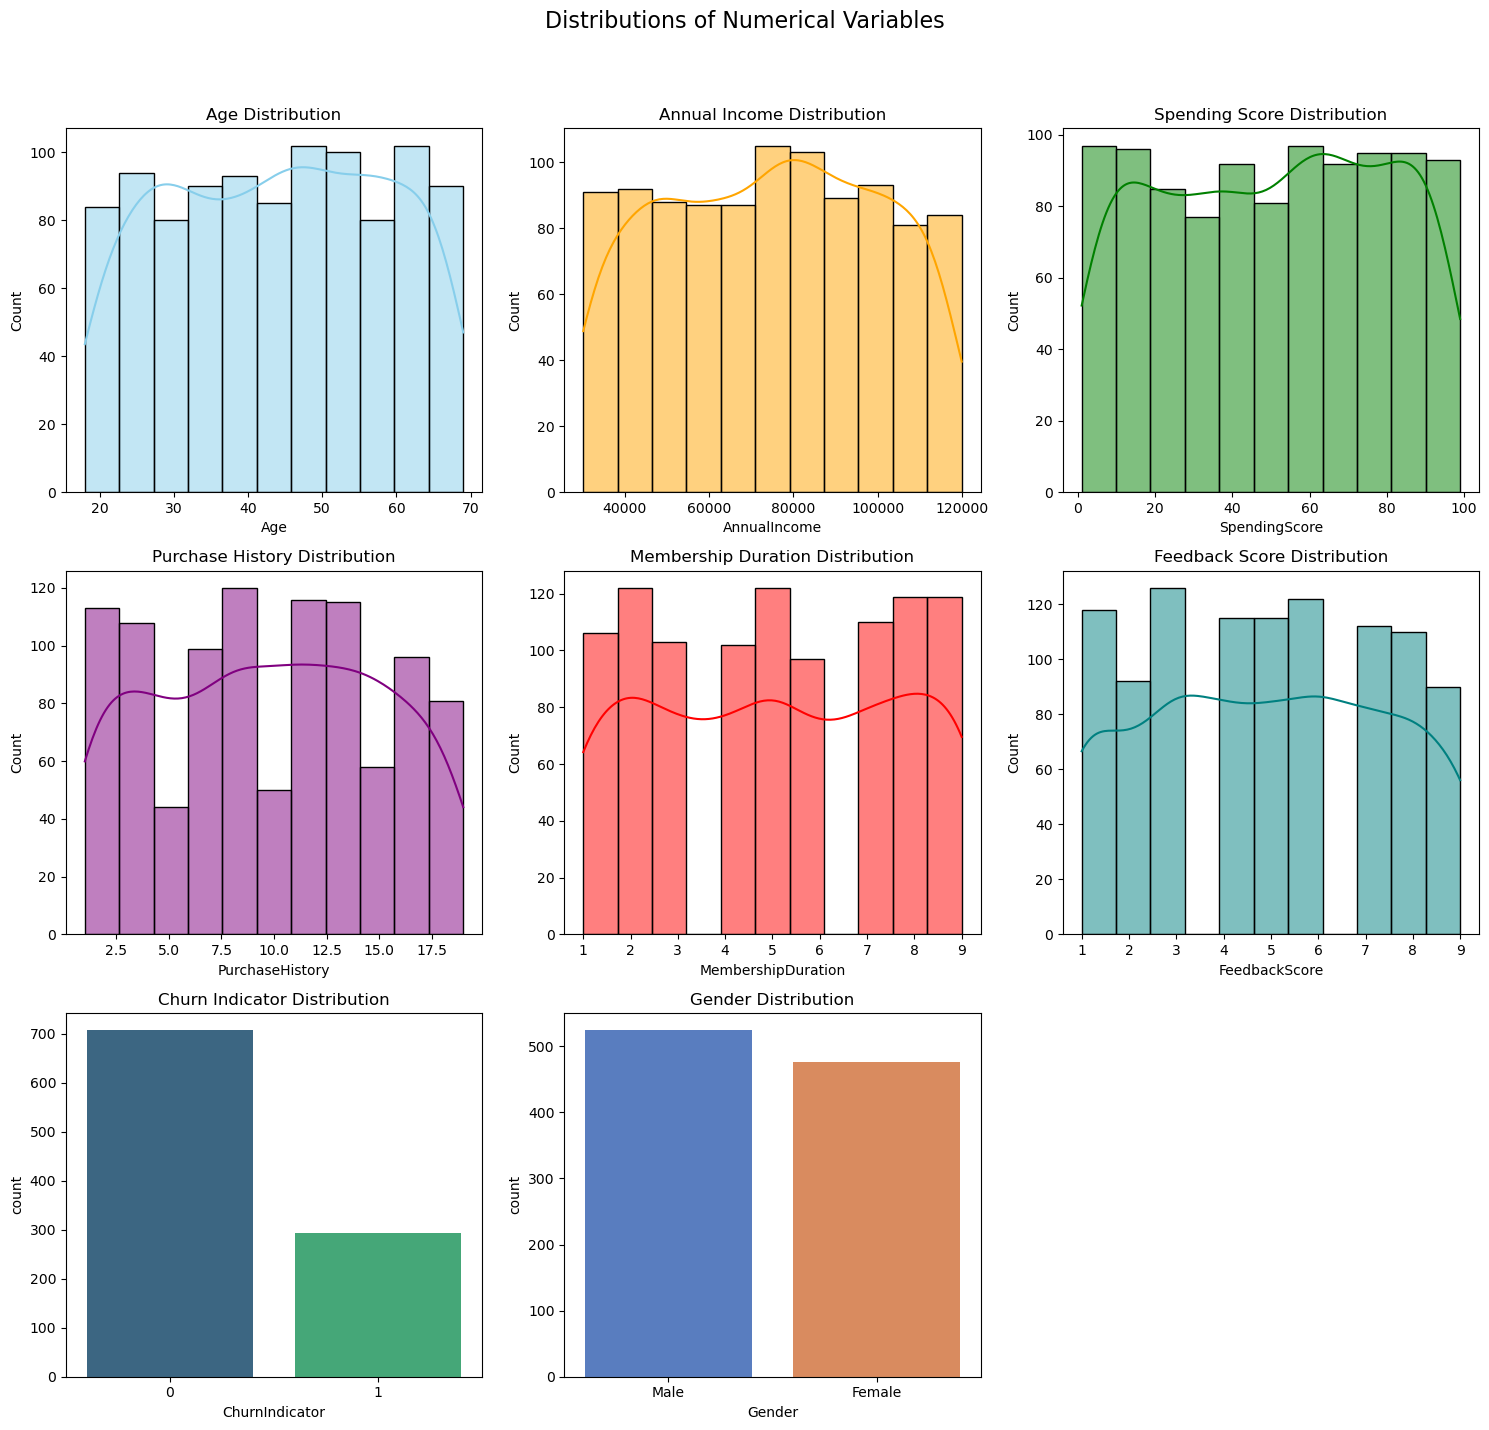

In [7]:
# Plot Distribution of Numerical variables
fig, axes = plt.subplots(3, 3, figsize=(15,15))
fig.suptitle("Distributions of Numerical Variables", fontsize=16)

# Age Distribution
sns.histplot(df['Age'], kde=True, ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Age Distribution")

# Annual Income Distribution
sns.histplot(df['AnnualIncome'], kde=True, ax=axes[0, 1], color="orange")
axes[0, 1].set_title("Annual Income Distribution")

# Spending Score Distribution
sns.histplot(df['SpendingScore'], kde=True, ax=axes[0, 2], color="green")
axes[0, 2].set_title("Spending Score Distribution")

# Purchase History Distribution
sns.histplot(df['PurchaseHistory'], kde=True, ax=axes[1, 0], color="purple")
axes[1, 0].set_title("Purchase History Distribution")

# Membership Duration Distribution
sns.histplot(df['MembershipDuration'], kde=True, ax=axes[1, 1], color="red")
axes[1, 1].set_title("Membership Duration Distribution")

# Feedback Score Distribution
sns.histplot(df['FeedbackScore'], kde=True, ax=axes[1, 2], color="teal")
axes[1, 2].set_title("Feedback Score Distribution")

# Churn IndicatorDistribution
sns.countplot(x='ChurnIndicator', data=df, ax=axes[2, 0], palette="viridis")
axes[2, 0].set_title("Churn Indicator Distribution")

# Gender Distribution
sns.countplot(x='Gender', data=df, ax=axes[2, 1], palette="muted")
axes[2, 1].set_title("Gender Distribution")

# Hide the last empty subplot
axes[2, 2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

- Age Distribution: Most customers fall between the ages of 30 and 60, with a slight peak around 45.
- Annual Income: A wide range of incomes, with a majority clustering between 50,000 and 100,000.
- Spending Score: Nearly uniform distribution with a slight peak around 60, indicating diverse spending behaviors.
- Purchase History: Most customers have 5-15 purchases, with fewer at the extremes.
- Membership Duration: Skewed towards shorter durations, with a peak at around 5 years.
- Feedback Score: Most customers rate their experience moderately (scores between 3 and 7).
- Churn Indicator: Approximately 70% of customers are retained (Churn Indicator = 0), , while 30% have churned  (Churn Indicator = 1).
- Gender Distribution: The dataset is relatively balanced: 52.4% Male and 47.6% Female.

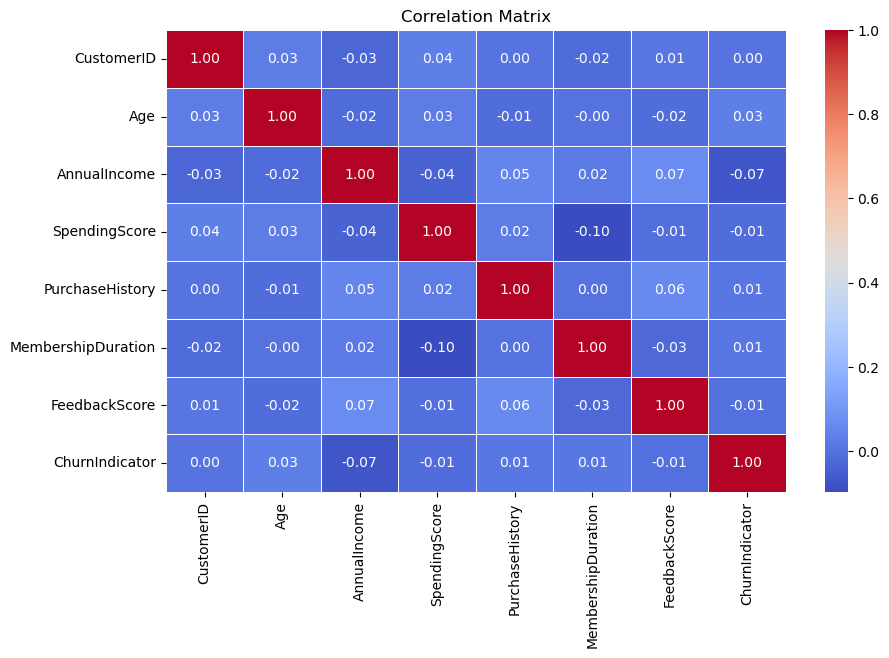

In [8]:
# Correlation heatmap to analyze relationships between numerical features and Churn Indicator
plt.figure(figsize=(10,6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot= True , cmap = 'coolwarm', fmt = ".2f", linewidth = 0.5)
plt.title("Correlation Matrix")
plt.show()

- Most correlations are very close to 0, which means there are no strong linear relationships between variables.
- The Churn Indicator has very weak correlation with all features → no single variable strongly explains churn on its own,indicating that customer behavior and churn are influenced by complex, non-linear interactions rather than individual features.

## *DATA CLEANING*

In [9]:
# Drop Duplicates
df.drop_duplicates(inplace=True)

In [10]:
# Handle Missing Values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace= True)
    else:
        df[col].fillna(df[col].median(), inplace =True)

In [11]:
# Encode categorical variables
from sklearn.preprocessing import StandardScaler, LabelEncoder

le =LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

## *FEATURE ENGINEERING*

In [12]:
# Customer Value Score
df['Customer_Value'] = df['SpendingScore'] * df['PurchaseHistory']

# Engagement Score
df['Engagement_Score'] = df['MembershipDuration'] * df['PurchaseHistory']

# Age Group
df['Age_Group'] = pd.cut(df['Age'],
                        bins=[18,30,45,60,100],
                        labels=['Young','Adult','Mid-Age','Senior'])

# Income Group
df['Income_Group'] = pd.cut(df['AnnualIncome'],
                           bins=[0, 30000, 70000, 150000],
                           labels=['Low','Medium', 'High'])

# Convert New Categorical features
df =pd.get_dummies(df, columns= ['Age_Group','Income_Group'], drop_first =True)

## *DEFINE FEATURES & TARGET*

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [14]:
X = df.drop(['CustomerID','ChurnIndicator'], axis=1)
y = df['ChurnIndicator']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

## *SCALING (for Logistic Regression)*

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## *MODEL 1: LOGISTIC REGRESSION*

In [32]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("\n--- Logistic Regression ---")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test,y_pred_lr))


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       140
           1       0.00      0.00      0.00        60

    accuracy                           0.70       200
   macro avg       0.35      0.50      0.41       200
weighted avg       0.49      0.70      0.58       200

ROC-AUC: 0.5


In [34]:
print("Logistic Regression Accuracy is:",
      metrics.accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy is: 0.7


## *MODEL 2: RANDOM FOREST*

In [36]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n--- Random Forest Classifier ---")
print(classification_report(y_test,y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test,y_pred_rf))


--- Random Forest Classifier ---
              precision    recall  f1-score   support

           0       0.70      0.94      0.80       140
           1       0.25      0.05      0.08        60

    accuracy                           0.67       200
   macro avg       0.47      0.49      0.44       200
weighted avg       0.56      0.67      0.58       200

ROC-AUC: 0.4928571428571429


In [38]:
print("Random Forest Classifier Accuracy is:",
      metrics.accuracy_score(y_test, y_pred_rf))

Random Forest Classifier Accuracy is: 0.67


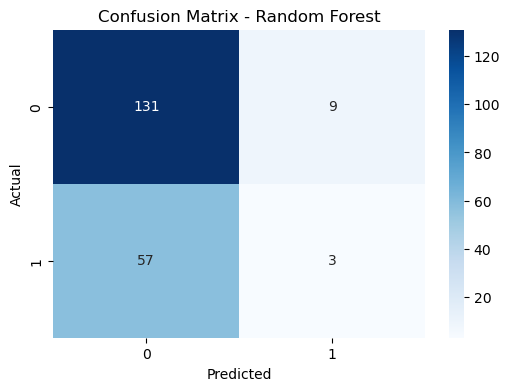

In [44]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
           annot =True, fmt ='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## *MODEL 3: XGBoost*

In [17]:
!pip install xgboost

     -------------------------------------- 124.9/124.9 MB 2.0 MB/s eta 0:00:00


In [23]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn import metrics

In [24]:
xgb = XGBClassifier(use_label_encoder=False,
                    eval_metric='logloss', random_state = 42)
xgb.fit(X_train, y_train)

y_pred_xgb =xgb.predict(X_test)

print('\n--- XGBoost (Base Model) ---')
print(classification_report(y_test, y_pred_xgb))
print("ROC_AUC:", roc_auc_score(y_test, y_pred_xgb))


--- XGBoost (Base Model) ---
              precision    recall  f1-score   support

           0       0.72      0.82      0.77       140
           1       0.38      0.25      0.30        60

    accuracy                           0.65       200
   macro avg       0.55      0.54      0.53       200
weighted avg       0.62      0.65      0.63       200

ROC_AUC: 0.5357142857142857


In [25]:
print("XGBoost Classifier accuracy is :", metrics.accuracy_score(y_test, y_pred_xgb))

XGBoost Classifier accuracy is : 0.65


## *HYPERPARAMETER TUNING (GridSearchCV)*

In [39]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [40]:
grid = GridSearchCV(
    estimator= XGBClassifier(
    use_label_encoder= False,
    eval_metric='logloss',
    random_state= 42
    ),
    param_grid=param_grid,
    scoring='recall',      # Important for churn
    cv = 3,
    verbose = 1,
    n_jobs = -1
)
grid.fit(X_train, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                   

In [42]:
print("Best Parameters:", grid.best_params_)

best_xgb = grid.best_estimator_

y_pred_best = best_xgb.predict(X_test)

print("\n--- Tuned XGBoost ---")
print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_best))

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

--- Tuned XGBoost ---
              precision    recall  f1-score   support

           0       0.71      0.87      0.78       140
           1       0.38      0.18      0.25        60

    accuracy                           0.67       200
   macro avg       0.55      0.53      0.52       200
weighted avg       0.61      0.67      0.62       200

ROC-AUC: 0.5273809523809524


In [ ]:
print("Best Parameters:", grid.best_params_)

best_xgb = grid.best_estimator_

y_pred_best = best_xgb.predict(X_test)

print("\n--- Tuned XGBoost ---")
print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_best))

## *CONFUSION MATRIX*

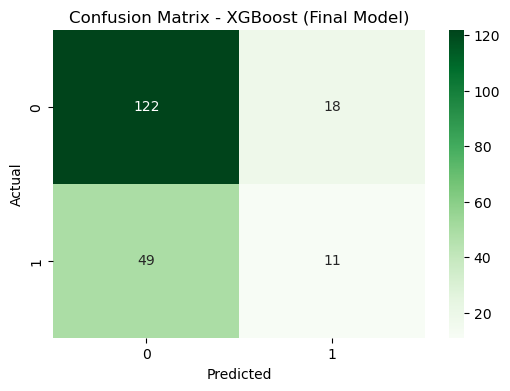

In [45]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - XGBoost (Final Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## *FEATURE IMPORTANCE*

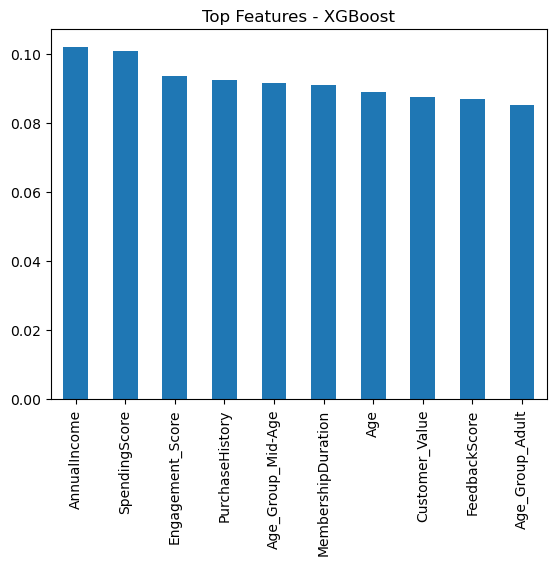

In [43]:
importances = pd.Series(best_xgb.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features - XGBoost")
plt.show()

### Final Insights (Confusion Matrix)
- Model correctly predicts most non-churn customers (122 TN)
- Detects some churn cases (11 TP) but still misses many (49 FN)
- Slight increase in false alarms (18 FP)

The model is biased toward non-churn and has low recall for churn customers

### Feature Importance Insights
- AnnualIncome is the single most predictive feature — demographics absolutely matter here.
- SpendingScore is a close second — spending behavior is equally important.
- Age-related features (Age, Age_Group_Mid-Age, Age_Group_Adult) appear three times in the top 10 — when combined, demographics arguably outweigh behavioral signals.
- The near-uniform spread suggests the model isn't over-relying on any one feature — it's learning from a broad combination of signals.

## Final Conclusion
- Model shows improvement in churn detection
- Still misses many churn customers (low recall)
- Good for analysis, but not fully ready for production

## Recommendations
- Improve recall using:
    - Threshold tuning (e.g., 0.3)
    - Class imbalance handling (SMOTE / weights)
- Business actions:
    - Focus on customer experience & feedback
    - Target low-engagement users
    - Strengthen loyalty programs

Model is directionally strong but requires recall optimization to effectively support real-world churn prevention.

In [ ]:
#import pickle

# Save model
#pickle.dump(best_xgb, open("model.pkl", "wb"))

In [47]:
#df['Churn_Predicted'] = best_xgb.predict(X)

In [48]:
#df.to_csv("final_data.csv", index=False)